**Name: Kaustubh Aswale**  
**Roll No: 69** 
**Assignment 4**

Create a Linear Regression Model using Python/R to predict home prices using Boston Housing Dataset
(https://www.kaggle.com/c/boston-housing). The Boston Housing dataset contains information about various
houses in Boston through different parameters. There are 506 samples and 14 feature variables in this dataset.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [3]:
# Load dataset
housing_data = fetch_california_housing()

housing_df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)

In [4]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
print("Shape and Size: ", housing_df.shape, housing_df.size)
housing_df['PRICE'] = housing_data.target

Shape and Size:  (20640, 8) 165120


In [6]:
# Basic Info
print("Shape:", housing_df.shape)
print("\nColumns:\n", housing_df.columns)
print("\nSummary:\n", housing_df.describe())

Shape: (20640, 9)

Columns:
 Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'PRICE'],
      dtype='str')

Summary:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         PRICE  
count  20640.000000  20640.000000  20640.00

In [7]:
# (Optional) Introduce missing values for demonstration
housing_df.loc[housing_df.sample(frac=0.05).index, 'MedInc'] = np.nan
# Check missing values
print("\nMissing Values:\n", housing_df.isnull().sum())


Missing Values:
 MedInc        1032
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
PRICE            0
dtype: int64


In [8]:
# Handling missing values (mean imputation)
housing_df.fillna(housing_df.mean(), inplace=True)
# Check missing values
print("\nMissing Values:\n", housing_df.isnull().sum())


Missing Values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64


In [9]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<Axes: >

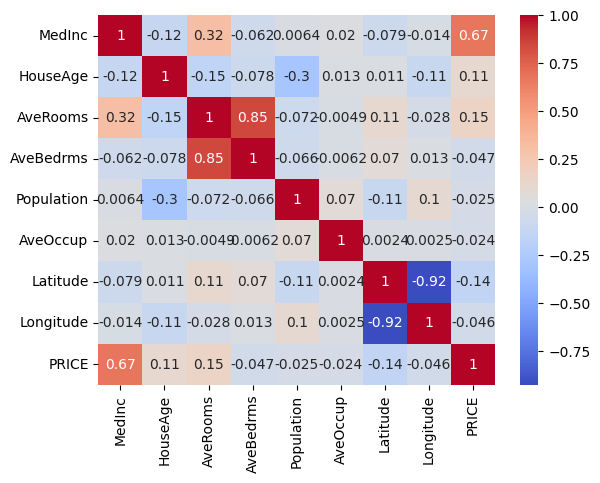

In [10]:
sns.heatmap(housing_df.corr(), annot=True, cmap='coolwarm')

In [11]:
# ORIGINAL MODEL
# ==============================

X = housing_df.drop("PRICE", axis=1)
y = housing_df["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

0.578998073461507

Number of outliers in PRICE: 1071


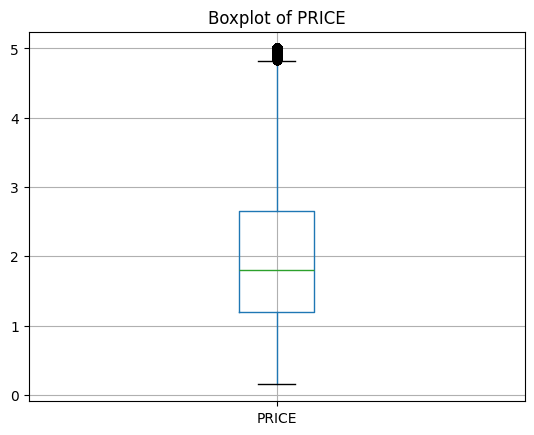

Original shape: (20640, 9)
Cleaned shape: (19569, 9)

===== CLEANED MODEL =====
RMSE: 0.64
R2: 0.55

===== COMPARISON =====
Original RMSE: 0.76 | Cleaned RMSE: 0.64
Original R2: 0.57 | Cleaned R2: 0.55


In [34]:
# OUTLIER DETECTION
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers_price, lower_bound, upper_bound = detect_outliers_iqr(housing_df, 'PRICE')

print("Number of outliers in PRICE:", len(outliers_price))

# VISUALIZATION
housing_df.boxplot(column='PRICE')
plt.title('Boxplot of PRICE')
plt.show()

# REMOVE OUTLIERS
housing_df_clean = housing_df[
    (housing_df['PRICE'] >= lower_bound) & 
    (housing_df['PRICE'] <= upper_bound)
]

print("Original shape:", housing_df.shape)
print("Cleaned shape:", housing_df_clean.shape)

# MODEL ON CLEAN DATA
X_clean = housing_df_clean.drop("PRICE", axis=1)
y_clean = housing_df_clean["PRICE"]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=10
)

scaler_clean = StandardScaler()
X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_clean_scaled = scaler_clean.transform(X_test_clean)

model_clean = LinearRegression()
model_clean.fit(X_train_clean_scaled, y_train_clean)

y_pred_clean = model_clean.predict(X_test_clean_scaled)

rmse_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
r2_clean = r2_score(y_test_clean, y_pred_clean)

# RESULTS
print("\n===== CLEANED MODEL =====")
print("RMSE:", round(rmse_clean, 2))
print("R2:", round(r2_clean, 2))

# COMPARISON
print("\n===== COMPARISON =====")
print("Original RMSE:", round(rmse, 2), "| Cleaned RMSE:", round(rmse_clean, 2))
print("Original R2:", round(r2, 2), "| Cleaned R2:", round(r2_clean, 2))

In [35]:
# Feature & Target split
X = housing_df.drop("PRICE", axis=1)
y = housing_df["PRICE"]

In [36]:
#Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

In [37]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [38]:
# Model Training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
# Predictions
y_pred = model.predict(X_test_scaled)

In [40]:
# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("Model Performance")
print("==============================")
print("RMSE:", rmse)
print("R2 Score:", round(r2, 2))


Model Performance
RMSE: 0.7627099959432827
R2 Score: 0.57


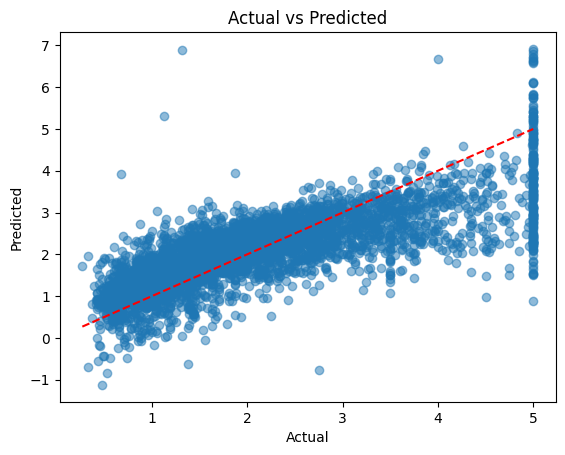

In [41]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.show()